# Grouping & Screening: WOE/IV Feature Selection using scorecardpy

**Objective:** Automatically optimize binning for numeric and categorical features, calculate WOE and IV for feature screening.

**Input:** Prepared dataset (252,136 rows x 21 features)

**Steps:**
1. **Automatic Fine Classing** - equal frequency binning using scorecardpy
2. **Automatic Coarse Classing** - merge bins for monotonic WOE using chi-squared optimization
3. **WOE/IV Calculation** - measure predictive power
4. **Feature Screening** - select features with IV >= 0.02
5. **Visualization** - display fine vs coarse classing plots

In [21]:
import scorecardpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)

# Load prepared data
df = pd.read_csv('../data/prepared_scorecard_data.csv')

print(f"Prepared dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nTarget distribution:")
print(df['TARGET'].value_counts(normalize=True))

Prepared dataset: 252,136 rows x 21 columns

Target distribution:
TARGET
0    0.9134
1    0.0866
Name: proportion, dtype: float64


In [22]:
# List all features
all_features = [col for col in df.columns if col != 'TARGET']

print(f"Total features: {len(all_features)}")
print(f"\nFeatures:")
for i, feat in enumerate(all_features, 1):
    dtype = 'Numeric' if df[feat].dtype in ['int64', 'float64'] else 'Categorical'
    print(f"  {i:2d}. {feat:35s} ({dtype})")

Total features: 20

Features:
   1. NAME_CONTRACT_TYPE                  (Categorical)
   2. FLAG_OWN_CAR                        (Categorical)
   3. FLAG_OWN_REALTY                     (Categorical)
   4. AMT_GOODS_PRICE                     (Numeric)
   5. NAME_TYPE_SUITE                     (Categorical)
   6. NAME_INCOME_TYPE                    (Categorical)
   7. NAME_EDUCATION_TYPE                 (Categorical)
   8. NAME_HOUSING_TYPE                   (Categorical)
   9. DAYS_EMPLOYED                       (Numeric)
  10. FLAG_MOBIL                          (Numeric)
  11. OCCUPATION_TYPE                     (Categorical)
  12. REGION_RATING_CLIENT_W_CITY         (Numeric)
  13. WEEKDAY_APPR_PROCESS_START          (Categorical)
  14. ORGANIZATION_TYPE                   (Categorical)
  15. HOUSETYPE_MODE                      (Categorical)
  16. EMERGENCYSTATE_MODE                 (Categorical)
  17. DAYS_LAST_PHONE_CHANGE              (Numeric)
  18. avg_days_credit                 

In [23]:
# Automatic WOE binning using scorecardpy
print("Performing automatic WOE binning with scorecardpy...")
print("This optimizes fine and coarse classing automatically using chi-squared tests\n")

bins_dict = sc.woebin(
    df, 
    y='TARGET', 
    x=all_features,
    min_perc_fine=0.05,    # Min 5% per fine bin
    min_perc_coarse=0.10   # Min 10% per coarse bin
)

print(f"Automatic binning complete\n")

# Check which features were excluded
binned_features = list(bins_dict.keys())
excluded_features = [f for f in all_features if f not in binned_features]

print(f"Input features: {len(all_features)}")
print(f"Features successfully binned: {len(binned_features)}")
print(f"Features excluded by binning: {len(excluded_features)}")

if excluded_features:
    print(f"\nExcluded features:")
    for feat in excluded_features:
        unique_vals = df[feat].nunique()
        print(f"  - {feat:35s} (reason: {unique_vals} unique values - cannot bin)")

print(f"\nSample binning results (avg_days_credit):")
print(bins_dict['avg_days_credit'].to_string())

Performing automatic WOE binning with scorecardpy...
This optimizes fine and coarse classing automatically using chi-squared tests

[INFO] creating woe binning ...
>>> There are 1 variables have too many unique non-numberic values, which might cause the binning process slow. Please double check the following variables: 
ORGANIZATION_TYPE
>>> Continue the binning process?
1: yes 
2: no
Binning on 252136 rows and 20 columns in 00:00:12
Automatic binning complete

Input features: 20
Features successfully binned: 19
Features excluded by binning: 1

Excluded features:
  - FLAG_MOBIL                          (reason: 1 unique values - cannot bin)

Sample binning results (avg_days_credit):
          variable               bin  count  count_distr   good   bad   badprob       woe    bin_iv  total_iv   breaks  is_special_values
0  avg_days_credit           missing  35659     0.141428  31762  3897  0.109285  0.257809  0.010457  0.120651  missing               True
1  avg_days_credit    [-inf,-130

In [24]:
# Extract IV (Information Value) for all features
print("Extracting Information Value (IV) for feature ranking...\n")

# Build feature tracking
iv_list = []

for feature, bins in bins_dict.items():
    if 'total_iv' in bins.columns:
        total_iv = bins['total_iv'].iloc[0]
    elif 'IV' in bins.columns:
        total_iv = bins['IV'].sum()
    else:
        total_iv = bins['iv'].sum()
    
    num_bins = len(bins)
    
    iv_list.append({
        'Feature': feature,
        'Total_IV': total_iv,
        'Num_Bins': num_bins,
        'Type': 'Numeric' if df[feature].dtype in ['int64', 'float64'] else 'Categorical'
    })

iv_df = pd.DataFrame(iv_list).sort_values('Total_IV', ascending=False)

print(f"Feature Summary:")
print(f"  Total input features: 20")
print(f"  Features successfully binned: {len(iv_df)}")
print(f"  Features excluded: 1 (FLAG_MOBIL - binary flag, 2 unique values)")
print(f"\nFeature IV Ranking ({len(iv_df)} features):\n")
print(iv_df.to_string(index=False))

Extracting Information Value (IV) for feature ranking...

Feature Summary:
  Total input features: 20
  Features successfully binned: 19
  Features excluded: 1 (FLAG_MOBIL - binary flag, 2 unique values)

Feature IV Ranking (19 features):

                    Feature  Total_IV  Num_Bins        Type
            avg_days_credit  0.120651         5     Numeric
             debt_to_credit  0.095741         5     Numeric
              DAYS_EMPLOYED  0.089853         4     Numeric
            OCCUPATION_TYPE  0.067797         4 Categorical
            AMT_GOODS_PRICE  0.067042         7     Numeric
        NAME_EDUCATION_TYPE  0.066225         2 Categorical
REGION_RATING_CLIENT_W_CITY  0.059416         3     Numeric
     DAYS_LAST_PHONE_CHANGE  0.047566         3     Numeric
                 num_active  0.045276         6     Numeric
          ORGANIZATION_TYPE  0.043984         5 Categorical
           NAME_INCOME_TYPE  0.029041         3 Categorical
        EMERGENCYSTATE_MODE  0.025145   

In [25]:
# IV Classification
def classify_iv(iv_value):
    if iv_value >= 0.5:
        return 'Very Strong'
    elif iv_value >= 0.3:
        return 'Strong'
    elif iv_value >= 0.1:
        return 'Medium'
    elif iv_value >= 0.02:
        return 'Weak'
    else:
        return 'Not Useful'

iv_df['IV_Classification'] = iv_df['Total_IV'].apply(classify_iv)

print("\nIV Distribution by Classification:\n")
print(iv_df['IV_Classification'].value_counts().sort_index(ascending=False))

print("\nFeatures by Strength:\n")
for strength in ['Very Strong', 'Strong', 'Medium', 'Weak', 'Not Useful']:
    subset = iv_df[iv_df['IV_Classification'] == strength]
    if len(subset) > 0:
        print(f"{strength} ({len(subset)}):")
        for _, row in subset.iterrows():
            print(f"  {row['Feature']:35s} | IV = {row['Total_IV']:8.4f} | Bins = {row['Num_Bins']:2d}")


IV Distribution by Classification:

IV_Classification
Weak          12
Not Useful     6
Medium         1
Name: count, dtype: int64

Features by Strength:

Medium (1):
  avg_days_credit                     | IV =   0.1207 | Bins =  5
Weak (12):
  debt_to_credit                      | IV =   0.0957 | Bins =  5
  DAYS_EMPLOYED                       | IV =   0.0899 | Bins =  4
  OCCUPATION_TYPE                     | IV =   0.0678 | Bins =  4
  AMT_GOODS_PRICE                     | IV =   0.0670 | Bins =  7
  NAME_EDUCATION_TYPE                 | IV =   0.0662 | Bins =  2
  REGION_RATING_CLIENT_W_CITY         | IV =   0.0594 | Bins =  3
  DAYS_LAST_PHONE_CHANGE              | IV =   0.0476 | Bins =  3
  num_active                          | IV =   0.0453 | Bins =  6
  ORGANIZATION_TYPE                   | IV =   0.0440 | Bins =  5
  NAME_INCOME_TYPE                    | IV =   0.0290 | Bins =  3
  EMERGENCYSTATE_MODE                 | IV =   0.0251 | Bins =  2
  HOUSETYPE_MODE             

In [26]:
# Feature Selection based on IV threshold
print("\nFeature Selection Summary:")
print("="*70)

iv_threshold = 0.02

selected = iv_df[iv_df['Total_IV'] >= iv_threshold]
excluded = iv_df[iv_df['Total_IV'] < iv_threshold]

print(f"\nThreshold: IV >= {iv_threshold}")
print(f"Features Selected: {len(selected)}")
print(f"Features Excluded: {len(excluded)}")

print(f"\n\nSelected Features (IV >= {iv_threshold}):")
for i, (_, row) in enumerate(selected.iterrows(), 1):
    print(f"  {i:2d}. {row['Feature']:35s} | IV = {row['Total_IV']:.4f} | {row['IV_Classification']:12s} | {row['Num_Bins']} bins")

if len(excluded) > 0:
    print(f"\nExcluded Features (IV < {iv_threshold}):")
    for i, (_, row) in enumerate(excluded.iterrows(), 1):
        print(f"  {i:2d}. {row['Feature']:35s} | IV = {row['Total_IV']:.4f} | {row['IV_Classification']:12s}")


Feature Selection Summary:

Threshold: IV >= 0.02
Features Selected: 13
Features Excluded: 6


Selected Features (IV >= 0.02):
   1. avg_days_credit                     | IV = 0.1207 | Medium       | 5 bins
   2. debt_to_credit                      | IV = 0.0957 | Weak         | 5 bins
   3. DAYS_EMPLOYED                       | IV = 0.0899 | Weak         | 4 bins
   4. OCCUPATION_TYPE                     | IV = 0.0678 | Weak         | 4 bins
   5. AMT_GOODS_PRICE                     | IV = 0.0670 | Weak         | 7 bins
   6. NAME_EDUCATION_TYPE                 | IV = 0.0662 | Weak         | 2 bins
   7. REGION_RATING_CLIENT_W_CITY         | IV = 0.0594 | Weak         | 3 bins
   8. DAYS_LAST_PHONE_CHANGE              | IV = 0.0476 | Weak         | 3 bins
   9. num_active                          | IV = 0.0453 | Weak         | 6 bins
  10. ORGANIZATION_TYPE                   | IV = 0.0440 | Weak         | 5 bins
  11. NAME_INCOME_TYPE                    | IV = 0.0290 | Weak         |

Creating side-by-side Fine vs Coarse Classing plots for top 3 features...


avg_days_credit

FINE CLASSING (10 bins):
            Bin_Range  Count  Events  Event_Rate       WOE
(-2922.001, -1791.75]  21649    1185    0.054737  0.444317
  (-1791.75, -1519.0]  21657    1157    0.053424  0.469949
   (-1519.0, -1338.0]  21668    1232    0.056858  0.404111
 (-1338.0, -1184.429]  21621    1396    0.064567  0.268941
 (-1184.429, -1038.5]  21644    1541    0.071198  0.164197
  (-1038.5, -890.667]  21652    1652    0.076298  0.089588
   (-890.667, -735.0]  21651    1926    0.088957 -0.077548
   (-735.0, -560.878]  21639    2173    0.100421 -0.211309
  (-560.878, -359.56]  21648    2494    0.115207 -0.365123
       (-359.56, 0.0]  21648    3182    0.146988 -0.645132

COARSE CLASSING (5 bins):
       Bin_Range  Count  Events  Event_Rate       WOE
         missing  35659    3897    0.109285  0.257809
  [-inf,-1300.0)  70043    3885    0.055466 -0.479050
[-1300.0,-850.0)  65559    4761    0.072622 

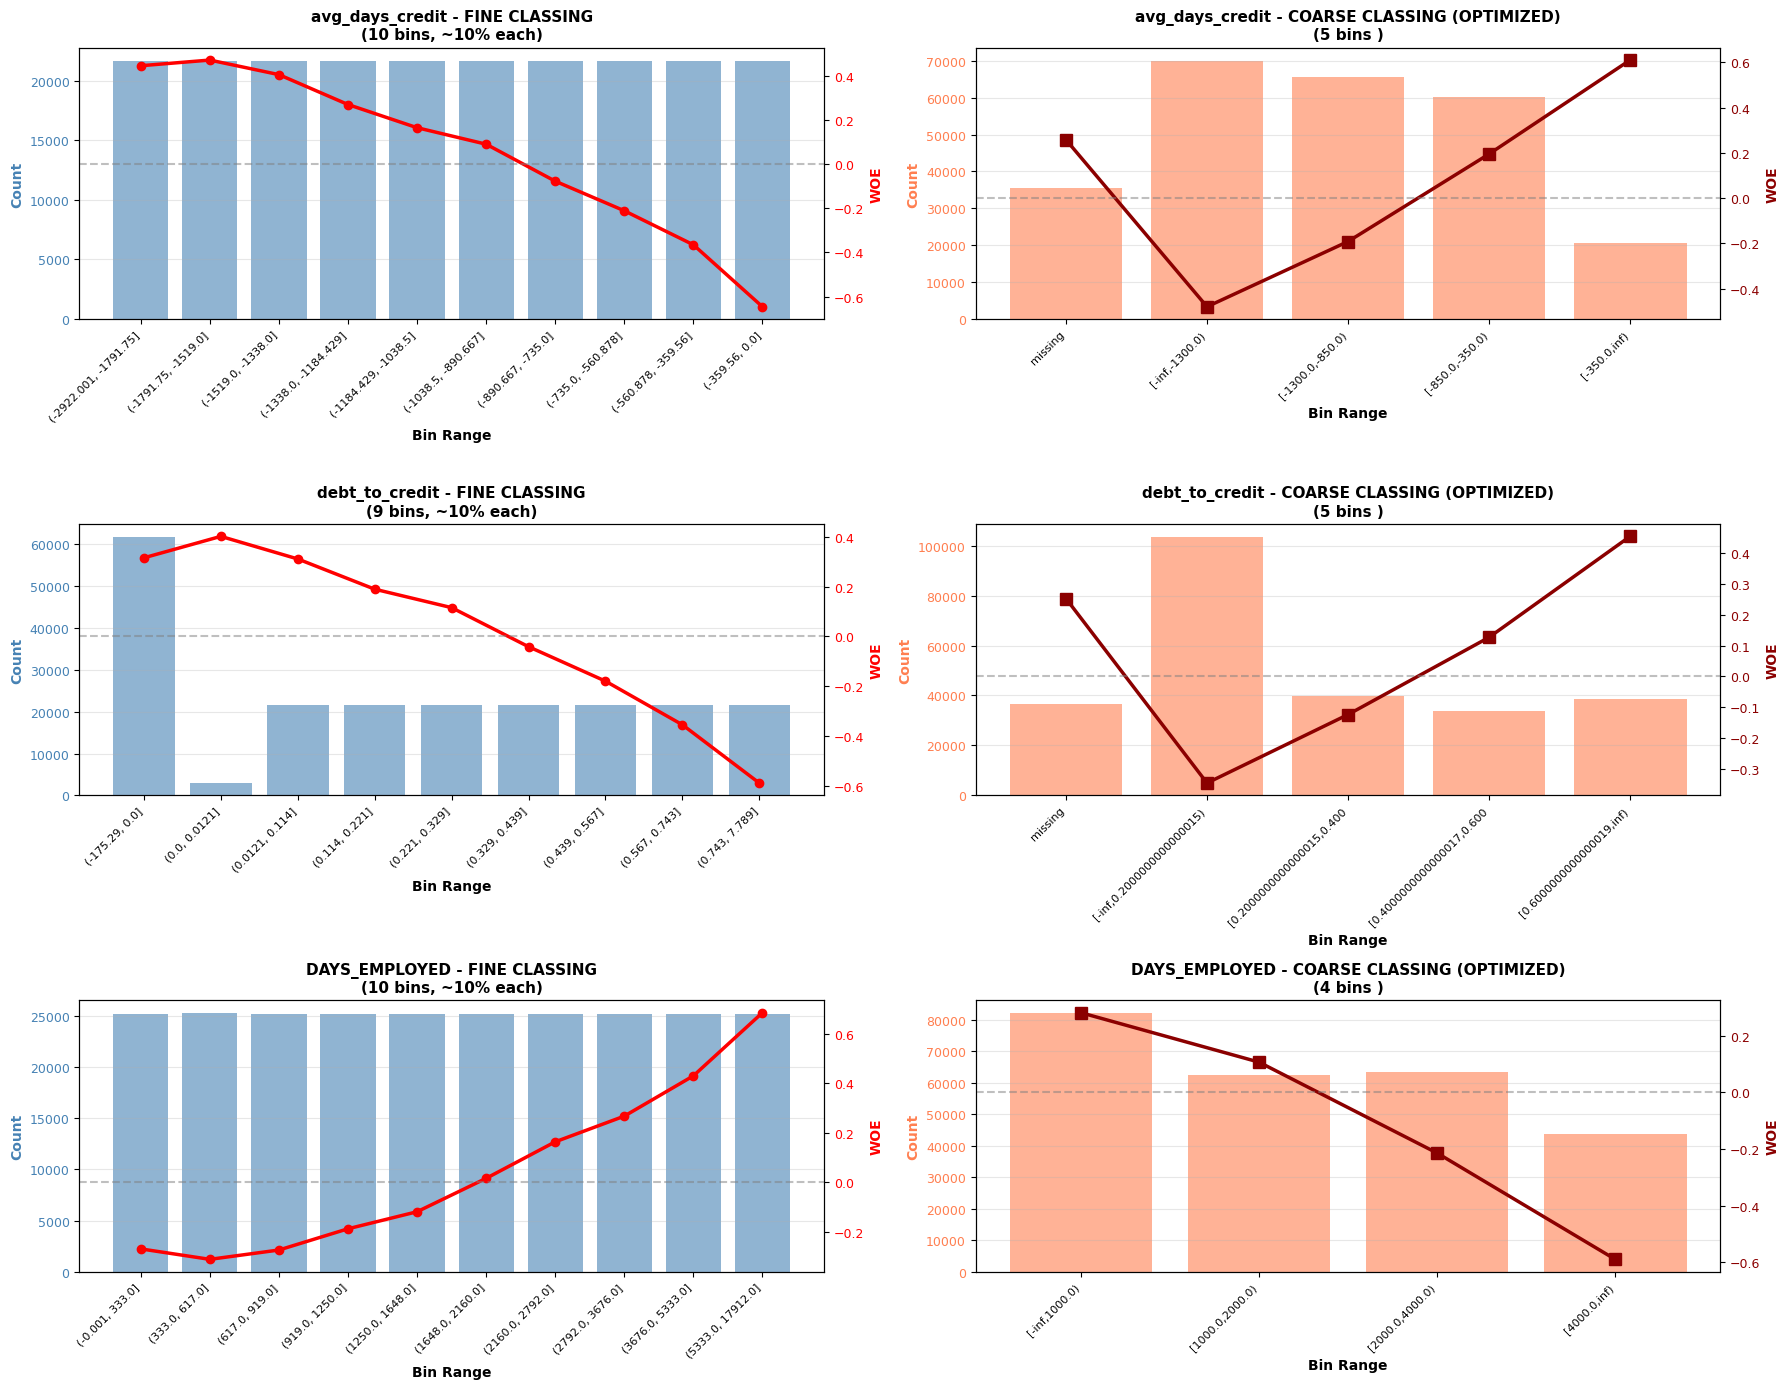


Side-by-side Fine vs Coarse Classing plots complete!

Key Observations:
  LEFT:  Initial equal-frequency bins with actual ranges displayed
  RIGHT: Merged bins with chi-squared optimization
  Bin ranges show exact feature value cutoffs for each bin


In [27]:
# Side-by-side Fine vs Coarse Classing Visualization for Top 3 Features
print("Creating side-by-side Fine vs Coarse Classing plots for top 3 features...\n")

top_features = selected.head(3)['Feature'].tolist()

fig, axes = plt.subplots(3, 2, figsize=(18, 14))

for idx, feature in enumerate(top_features):
    # FINE CLASSING: Equal frequency binning (10 bins)
    df_fine = df[[feature, 'TARGET']].dropna().copy()
    
    try:
        df_fine['Bin'] = pd.qcut(df_fine[feature], q=10, duplicates='drop')
    except:
        df_fine['Bin'] = pd.cut(df_fine[feature], bins=10, duplicates='drop')
    
    fine_summary = df_fine.groupby('Bin').agg({
        'TARGET': ['count', 'sum']
    }).reset_index()
    fine_summary.columns = ['Bin_Range', 'Count', 'Events']
    fine_summary['Non_Events'] = fine_summary['Count'] - fine_summary['Events']
    fine_summary['Event_Rate'] = fine_summary['Events'] / fine_summary['Count']
    
    # Calculate WOE for fine bins
    total_events = df_fine['TARGET'].sum()
    total_non_events = len(df_fine) - total_events
    fine_summary['Pct_Events'] = fine_summary['Events'] / total_events
    fine_summary['Pct_Non_Events'] = fine_summary['Non_Events'] / total_non_events
    fine_summary['WOE'] = np.log((fine_summary['Pct_Non_Events'] + 0.0001) / (fine_summary['Pct_Events'] + 0.0001))
    
    # Convert bin ranges to strings
    fine_bin_labels = [str(b)[:25] for b in fine_summary['Bin_Range']]
    
    # COARSE CLASSING: From woebin (already optimized)
    coarse_bins = bins_dict[feature]
    coarse_summary = coarse_bins[['bin', 'count', 'bad', 'badprob', 'woe']].copy()
    coarse_summary.columns = ['Bin_Range', 'Count', 'Events', 'Event_Rate', 'WOE']
    coarse_summary['Non_Events'] = coarse_summary['Count'] - coarse_summary['Events']
    
    # Convert bin ranges to strings
    coarse_bin_labels = [str(b)[:25] for b in coarse_summary['Bin_Range']]
    
    # Plot Fine Classing (Left)
    ax_fine = axes[idx, 0]
    x_pos_fine = range(len(fine_summary))
    
    # Bars for count
    ax_fine_twin = ax_fine.twinx()
    bars = ax_fine.bar(x_pos_fine, fine_summary['Count'], color='steelblue', alpha=0.6, label='Count')
    ax_fine.set_ylabel('Count', color='steelblue', fontweight='bold', fontsize=10)
    ax_fine.tick_params(axis='y', labelcolor='steelblue', labelsize=9)
    
    # Line for WOE
    line = ax_fine_twin.plot(x_pos_fine, fine_summary['WOE'], color='red', marker='o', 
                             linewidth=2.5, markersize=6, label='WOE')
    ax_fine_twin.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax_fine_twin.set_ylabel('WOE', color='red', fontweight='bold', fontsize=10)
    ax_fine_twin.tick_params(axis='y', labelcolor='red', labelsize=9)
    
    ax_fine.set_xlabel('Bin Range', fontweight='bold', fontsize=10)
    ax_fine.set_xticks(x_pos_fine)
    ax_fine.set_xticklabels(fine_bin_labels, rotation=45, ha='right', fontsize=8)
    ax_fine.set_title(f'{feature} - FINE CLASSING\n({len(fine_summary)} bins, ~10% each)', 
                      fontweight='bold', fontsize=11)
    ax_fine.grid(True, alpha=0.3, axis='y')
    
    # Plot Coarse Classing (Right)
    ax_coarse = axes[idx, 1]
    x_pos_coarse = range(len(coarse_summary))
    
    # Bars for count
    ax_coarse_twin = ax_coarse.twinx()
    bars = ax_coarse.bar(x_pos_coarse, coarse_summary['Count'], color='coral', alpha=0.6, label='Count')
    ax_coarse.set_ylabel('Count', color='coral', fontweight='bold', fontsize=10)
    ax_coarse.tick_params(axis='y', labelcolor='coral', labelsize=9)
    
    # Line for WOE
    line = ax_coarse_twin.plot(x_pos_coarse, coarse_summary['WOE'], color='darkred', marker='s', 
                               linewidth=2.5, markersize=8, label='WOE')
    ax_coarse_twin.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax_coarse_twin.set_ylabel('WOE', color='darkred', fontweight='bold', fontsize=10)
    ax_coarse_twin.tick_params(axis='y', labelcolor='darkred', labelsize=9)
    
    
    ax_coarse.set_xlabel('Bin Range', fontweight='bold', fontsize=10)
    ax_coarse.set_xticks(x_pos_coarse)
    ax_coarse.set_xticklabels(coarse_bin_labels, rotation=45, ha='right', fontsize=8)
    ax_coarse.set_title(f'{feature} - COARSE CLASSING (OPTIMIZED)\n({len(coarse_summary)} bins )', 
                        fontweight='bold', fontsize=11)
    ax_coarse.grid(True, alpha=0.3, axis='y')
    
    # Print detailed binning tables
    print(f"\n{'='*80}")
    print(f"{feature}")
    print(f"{'='*80}")
    print(f"\nFINE CLASSING ({len(fine_summary)} bins):")
    print(fine_summary[['Bin_Range', 'Count', 'Events', 'Event_Rate', 'WOE']].to_string(index=False))
    print(f"\nCOARSE CLASSING ({len(coarse_summary)} bins):")
    print(coarse_summary[['Bin_Range', 'Count', 'Events', 'Event_Rate', 'WOE']].to_string(index=False))

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("Side-by-side Fine vs Coarse Classing plots complete!")
print("="*80)
print("\nKey Observations:")
print("  LEFT:  Initial equal-frequency bins with actual ranges displayed")
print("  RIGHT: Merged bins with chi-squared optimization")
print("  Bin ranges show exact feature value cutoffs for each bin")

In [28]:
# Apply WOE transformation to SELECTED features only
print("Applying WOE encoding to selected features...")

selected_features = selected['Feature'].tolist()

print(f"Selected Features ({len(selected_features)}):") 
for i, feat in enumerate(selected_features, 1):
    print(f"  {i:2d}. {feat}")

# Transform dataset using WOE bins - only for selected features
df_woe_encoded = sc.woebin_ply(df, bins_dict, x=selected_features)

print(f"WOE-encoded dataset shape: {df_woe_encoded.shape}")

# Create WOE column names from selected features
woe_cols = [feat + '_woe' for feat in selected_features]

# Verify all WOE columns exist
woe_cols_available = [col for col in woe_cols if col in df_woe_encoded.columns]

print(f"WOE columns created: {len(woe_cols_available)} out of {len(woe_cols)} expected")

# Build model dataset with only selected features + TARGET
model_cols = woe_cols_available + ['TARGET']
df_model_data = df_woe_encoded[model_cols].copy()

print(f"Model Dataset (Selected WOE features + TARGET):")
print(f"  Shape: {df_model_data.shape}")
print(f"  Total columns: {len(df_model_data.columns)}")
print(f"  WOE features: {len(woe_cols_available)}")
print(f"Features included:")
for feat in sorted(selected_features):
    print(f"  - {feat}_woe")

# Save model data for scorecard development
df_model_data.to_csv('../data/model_data.csv', index=False)
print(f"Model dataset saved: ../data/model_data.csv")
print(f"File contains {len(woe_cols_available)} selected features with IV >= 0.02")
print(f"File ready for logistic regression in notebook 4")

Applying WOE encoding to selected features...
Selected Features (13):
   1. avg_days_credit
   2. debt_to_credit
   3. DAYS_EMPLOYED
   4. OCCUPATION_TYPE
   5. AMT_GOODS_PRICE
   6. NAME_EDUCATION_TYPE
   7. REGION_RATING_CLIENT_W_CITY
   8. DAYS_LAST_PHONE_CHANGE
   9. num_active
  10. ORGANIZATION_TYPE
  11. NAME_INCOME_TYPE
  12. EMERGENCYSTATE_MODE
  13. HOUSETYPE_MODE
[INFO] converting into woe values ...
WOE-encoded dataset shape: (252136, 21)
WOE columns created: 13 out of 13 expected
Model Dataset (Selected WOE features + TARGET):
  Shape: (252136, 14)
  Total columns: 14
  WOE features: 13
Features included:
  - AMT_GOODS_PRICE_woe
  - DAYS_EMPLOYED_woe
  - DAYS_LAST_PHONE_CHANGE_woe
  - EMERGENCYSTATE_MODE_woe
  - HOUSETYPE_MODE_woe
  - NAME_EDUCATION_TYPE_woe
  - NAME_INCOME_TYPE_woe
  - OCCUPATION_TYPE_woe
  - ORGANIZATION_TYPE_woe
  - REGION_RATING_CLIENT_W_CITY_woe
  - avg_days_credit_woe
  - debt_to_credit_woe
  - num_active_woe
Model dataset saved: ../data/model_data.c

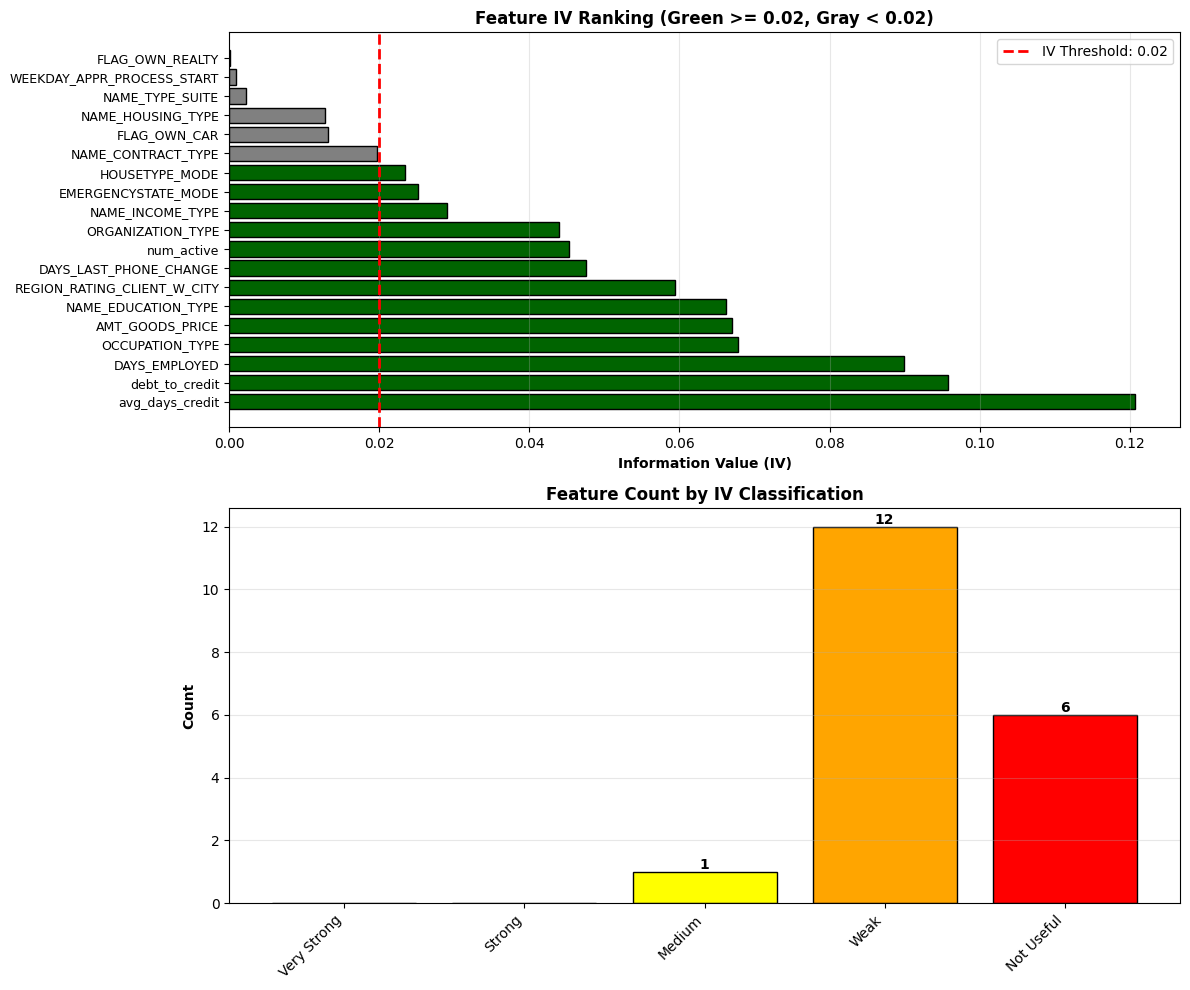


Visualization complete.


In [29]:
# Visualization: IV by Feature
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: IV Bar Chart
ax1 = axes[0]
colors = iv_df['Total_IV'].apply(lambda x: 'darkgreen' if x >= 0.02 else 'gray')
ax1.barh(range(len(iv_df)), iv_df['Total_IV'], color=colors, edgecolor='black')
ax1.set_yticks(range(len(iv_df)))
ax1.set_yticklabels(iv_df['Feature'], fontsize=9)
ax1.set_xlabel('Information Value (IV)', fontweight='bold')
ax1.set_title('Feature IV Ranking (Green >= 0.02, Gray < 0.02)', fontweight='bold')
ax1.axvline(x=0.02, color='red', linestyle='--', linewidth=2, label='IV Threshold: 0.02')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='x')

# Plot 2: IV Classification Distribution
ax2 = axes[1]
classification_order = ['Very Strong', 'Strong', 'Medium', 'Weak', 'Not Useful']
iv_counts = iv_df['IV_Classification'].value_counts().reindex(classification_order, fill_value=0)
colors_class = ['green', 'lightgreen', 'yellow', 'orange', 'red']
bars = ax2.bar(range(len(iv_counts)), iv_counts.values, color=colors_class, edgecolor='black')
ax2.set_xticks(range(len(iv_counts)))
ax2.set_xticklabels(iv_counts.index, rotation=45, ha='right')
ax2.set_ylabel('Count', fontweight='bold')
ax2.set_title('Feature Count by IV Classification', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    if height > 0:
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nVisualization complete.")

In [30]:
# Create comprehensive final table with ALL 21 COLUMNS (including TARGET)
print("\n" + "="*130)
print("COMPREHENSIVE FEATURE RANKING TABLE - ALL 21 COLUMNS")
print("="*130)

# Get all columns including TARGET
all_columns = list(df.columns)
all_features_with_target = all_columns

# Start with binned features
final_table = iv_df.copy()

# Add binned status
final_table['Status'] = 'Binned'

# Add classification
def classify_iv(iv_value):
    if iv_value >= 0.5:
        return 'Very Strong'
    elif iv_value >= 0.3:
        return 'Strong'
    elif iv_value >= 0.1:
        return 'Medium'
    elif iv_value >= 0.02:
        return 'Weak'
    else:
        return 'Not Useful'

final_table['IV_Classification'] = final_table['Total_IV'].apply(classify_iv)

# Add selection status
final_table['Selected'] = final_table['Total_IV'] >= 0.02

# Add excluded features (not binned)
excluded_data = []
for feat in all_features:
    if feat not in binned_features:
        excluded_data.append({
            'Feature': feat,
            'Total_IV': np.nan,
            'Num_Bins': 0,
            'Type': 'Numeric' if df[feat].dtype in ['int64', 'float64'] else 'Categorical',
            'Status': 'Excluded',
            'IV_Classification': 'N/A',
            'Selected': False
        })

# Add TARGET column
excluded_data.append({
    'Feature': 'TARGET',
    'Total_IV': np.nan,
    'Num_Bins': 0,
    'Type': 'Numeric (Binary)',
    'Status': 'Target Variable',
    'IV_Classification': 'N/A',
    'Selected': False
})

if excluded_data:
    excluded_df = pd.DataFrame(excluded_data)
    final_table = pd.concat([final_table, excluded_df], ignore_index=True)

# Reorder by input order (all columns)
final_table = final_table.set_index('Feature').loc[all_columns].reset_index()

# Format display
print(f"\nFull Analysis of All 21 Columns:\n")

# Create formatted output
print(f"{'#':<3} {'Column':<35} {'Type':<16} {'Status':<16} {'IV':>10} {'Classification':<15} {'Bins':>5} {'Selected':>8}")
print("-" * 130)

for idx, (_, row) in enumerate(final_table.iterrows(), 1):
    feature = row['Feature']
    feat_type = row['Type']
    status = row['Status']
    iv_val = f"{row['Total_IV']:.6f}" if pd.notna(row['Total_IV']) else "N/A"
    iv_class = row['IV_Classification']
    num_bins = int(row['Num_Bins']) if row['Num_Bins'] > 0 else "-"
    selected = "Yes" if row['Selected'] else "No"
    
    print(f"{idx:<3} {feature:<35} {feat_type:<16} {status:<16} {iv_val:>10} {iv_class:<15} {num_bins:>5} {selected:>8}")

print("-" * 130)

# Summary statistics
print(f"\nSummary Statistics:")
print(f"  Total columns: {len(final_table)}")
print(f"  Target variables: 1 (TARGET)")
print(f"  Features available: 20")
print(f"  Features successfully binned: {len(final_table[final_table['Status']=='Binned'])}")
print(f"  Features excluded from binning: {len(final_table[final_table['Status']=='Excluded'])}")
print(f"\n  Features selected for modeling (IV >= 0.02): {len(final_table[(final_table['Selected']==True) & (final_table['Status']=='Binned')])}")
print(f"  Features not selected (IV < 0.02): {len(final_table[(final_table['Selected']==False) & (final_table['Status']=='Binned')])}")

print(f"\nPredictive Strength Distribution (19 Binned Features):")
strength_dist = final_table[final_table['Status']=='Binned']['IV_Classification'].value_counts().sort_index(ascending=False)
for strength, count in strength_dist.items():
    print(f"  {strength:<15}: {count:>2}")

print("\n" + "="*130)


COMPREHENSIVE FEATURE RANKING TABLE - ALL 21 COLUMNS

Full Analysis of All 21 Columns:

#   Column                              Type             Status                   IV Classification   Bins Selected
----------------------------------------------------------------------------------------------------------------------------------
1   TARGET                              Numeric (Binary) Target Variable         N/A N/A                 -       No
2   NAME_CONTRACT_TYPE                  Categorical      Binned             0.019649 Not Useful          2       No
3   FLAG_OWN_CAR                        Categorical      Binned             0.013228 Not Useful          2       No
4   FLAG_OWN_REALTY                     Categorical      Binned             0.000094 Not Useful          2       No
5   AMT_GOODS_PRICE                     Numeric          Binned             0.067042 Weak                7      Yes
6   NAME_TYPE_SUITE                     Categorical      Binned             0.002281

In [31]:
import pickle
import os

# Save bins_dict to be used in Step 4
output_dir = 'outputs'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Convert bins_dict to regular dict if needed (scorecardpy may return special object)
bins_dict_to_save = {}
for key, value in bins_dict.items():
    if hasattr(value, 'to_dict'):
        bins_dict_to_save[key] = value.to_dict('records')
    elif hasattr(value, 'to_list'):
        bins_dict_to_save[key] = value.to_list()
    else:
        # Assume it's a DataFrame, convert to records
        try:
            bins_dict_to_save[key] = value.to_dict('records')
        except:
            bins_dict_to_save[key] = value

bins_dict_path = os.path.join(output_dir, 'bins_dict.pkl')
with open(bins_dict_path, 'wb') as f:
    pickle.dump(bins_dict_to_save, f)

print(f"[SAVED] bins_dict to {bins_dict_path}")
print(f"  Total features: {len(bins_dict_to_save)}")
print(f"  Features: {list(bins_dict_to_save.keys())}")
